<a href="https://colab.research.google.com/github/apirakqqqqq/Ge338-GEOGRAPHIC-DATA-SCIENCE/blob/main/Lab_2/Untitled5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install geopandas rasterio folium shapely matplotlib -q

import rasterio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


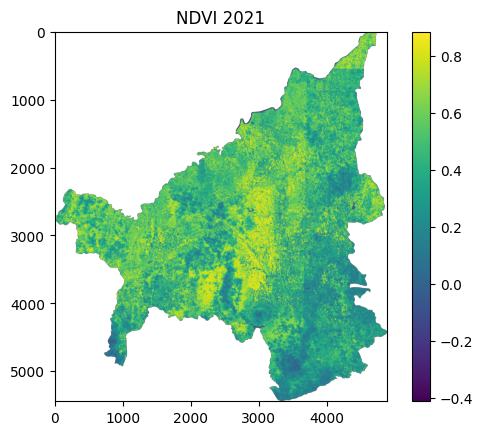

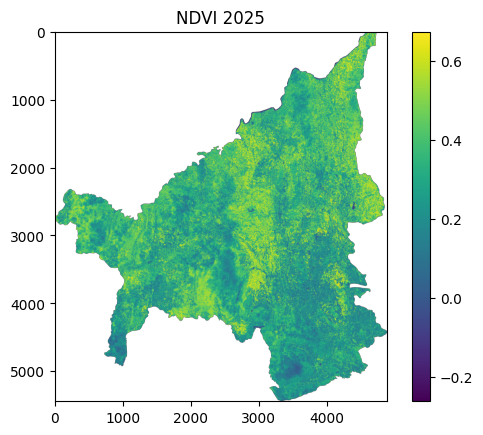

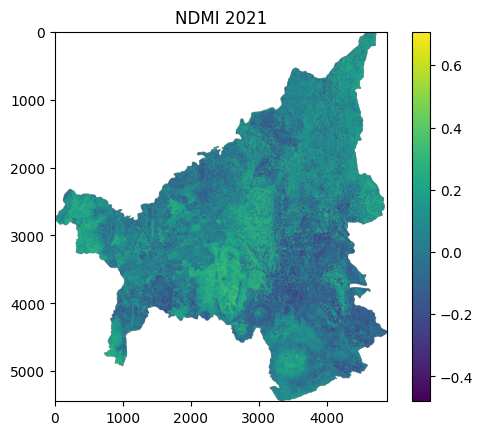

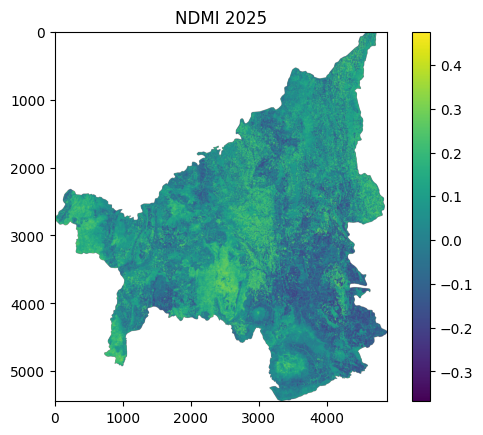

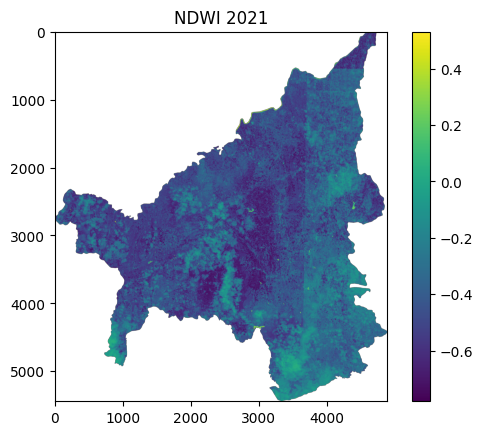

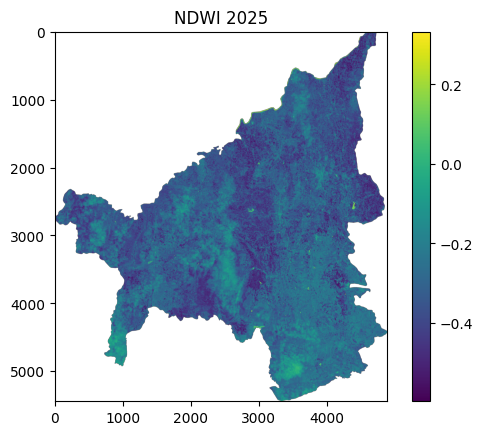

In [4]:
import rasterio
import matplotlib.pyplot as plt

# =======================
# LOAD DATA
# =======================
file21 = "/content/drive/MyDrive/ไฟล์/Loei_Indices_2021_FIX_FINAL.tif"
file25 = "/content/drive/MyDrive/ไฟล์/Loei_Indices_2025_FIX_FINAL.tif"

src21 = rasterio.open(file21)
src25 = rasterio.open(file25)

# อ่าน band
ndvi21, ndmi21, ndwi21 = src21.read()
ndvi25, ndmi25, ndwi25 = src25.read()

# =======================
# VISUALIZATION (เทียบกัน)
# =======================
def show(img, title):
    plt.imshow(img)
    plt.title(title)
    plt.colorbar()
    plt.show()

show(ndvi21, "NDVI 2021")
show(ndvi25, "NDVI 2025")

show(ndmi21, "NDMI 2021")
show(ndmi25, "NDMI 2025")

show(ndwi21, "NDWI 2021")
show(ndwi25, "NDWI 2025")

In [6]:
# =======================
# 1. โหลด shapefile (อำเภอ)
# =======================
shp = gpd.read_file("/content/drive/MyDrive/ไฟล์/LU_LEI_2565.shp")

# =======================
# 2. แปลง CRS ให้ตรงกัน
# =======================
shp = shp.to_crs(src25.crs)

# =======================
# 3. Zonal Statistics
# =======================
results = []

for i, row in shp.iterrows():
    geom = [row.geometry]

    try:
        out_img, _ = mask(src25, geom, crop=True)

        ndvi_zone = out_img[0]  # band 1 = NDVI
        ndvi_zone = ndvi_zone[~np.isnan(ndvi_zone)]

        mean_val = ndvi_zone.mean() if len(ndvi_zone) > 0 else None

    except:
        mean_val = None

    results.append(mean_val)

# =======================
# 5. เพิ่มเข้า shapefile
# =======================
shp["NDVI_mean_2025"] = results

print(shp.head())

   LU_ID_L1  LU_ID_L2  LU_ID_L3 LU_CODE                 LU_DES_TH  \
0       2.0      20.0    2001.0    A001  เกษตรผสมผสาน/ไร่นาสวนผสม   
1       2.0      20.0    2001.0    A001  เกษตรผสมผสาน/ไร่นาสวนผสม   
2       2.0      20.0    2001.0    A001  เกษตรผสมผสาน/ไร่นาสวนผสม   
3       2.0      20.0    2001.0    A001  เกษตรผสมผสาน/ไร่นาสวนผสม   
4       2.0      20.0    2001.0    A001  เกษตรผสมผสาน/ไร่นาสวนผสม   

                          LU_DES_EN LUL1_CODE LUL2_CODE LU_DES    Shape_Area  \
0  Integrated farm/Diversified farm         A        A0   None   8656.991843   
1  Integrated farm/Diversified farm         A        A0   None  24462.095559   
2  Integrated farm/Diversified farm         A        A0   None  25193.060008   
3  Integrated farm/Diversified farm         A        A0   None  23054.887834   
4  Integrated farm/Diversified farm         A        A0   None  49801.140906   

   RAI                                           geometry  NDVI_mean_2025  
0    5  POLYGON ((101.88984 

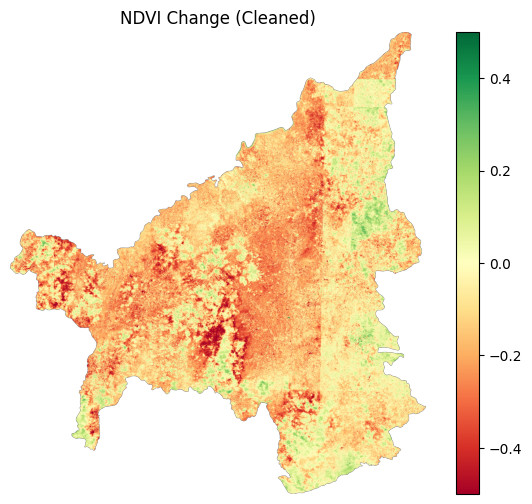

=== FIXED RESULT ===
Increase: 5.66%
Decrease: 55.58%
Stable: 38.77%


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.warp import reproject, Resampling

# =======================
# 1. เปิด raster
# =======================
src21 = rasterio.open(file21)
src25 = rasterio.open(file25)

ndvi21 = src21.read(1)
ndvi25_raw = src25.read(1)

# =======================
# 2. align raster (สำคัญมาก)
# =======================
ndvi25 = np.empty_like(ndvi21)

reproject(
    source=ndvi25_raw,
    destination=ndvi25,
    src_transform=src25.transform,
    src_crs=src25.crs,
    dst_transform=src21.transform,
    dst_crs=src21.crs,
    resampling=Resampling.bilinear
)

# =======================
# 3. mask nodata
# =======================
nodata21 = src21.nodata
nodata25 = src25.nodata

mask_valid = (
    (ndvi21 != nodata21) &
    (ndvi25 != nodata25) &
    (~np.isnan(ndvi21)) &
    (~np.isnan(ndvi25))
)

ndvi21 = np.where(mask_valid, ndvi21, np.nan)
ndvi25 = np.where(mask_valid, ndvi25, np.nan)

# =======================
# 4. คำนวณ diff
# =======================
diff = ndvi25 - ndvi21

# =======================
# 5. threshold (ปรับให้ realistic)
# =======================
increase = diff > 0.1
decrease = diff < -0.1
stable = (diff >= -0.1) & (diff <= 0.1)

# =======================
# 6. plot แบบ clean
# =======================
plt.figure(figsize=(8,6))
plt.imshow(diff, cmap='RdYlGn', vmin=-0.5, vmax=0.5)
plt.title("NDVI Change (Cleaned)")
plt.colorbar()
plt.axis('off')
plt.show()

# =======================
# 7. summary
# =======================
total = np.sum(~np.isnan(diff))

inc = np.sum(increase) / total * 100
dec = np.sum(decrease) / total * 100
sta = np.sum(stable) / total * 100

print("=== FIXED RESULT ===")
print(f"Increase: {inc:.2f}%")
print(f"Decrease: {dec:.2f}%")
print(f"Stable: {sta:.2f}%")

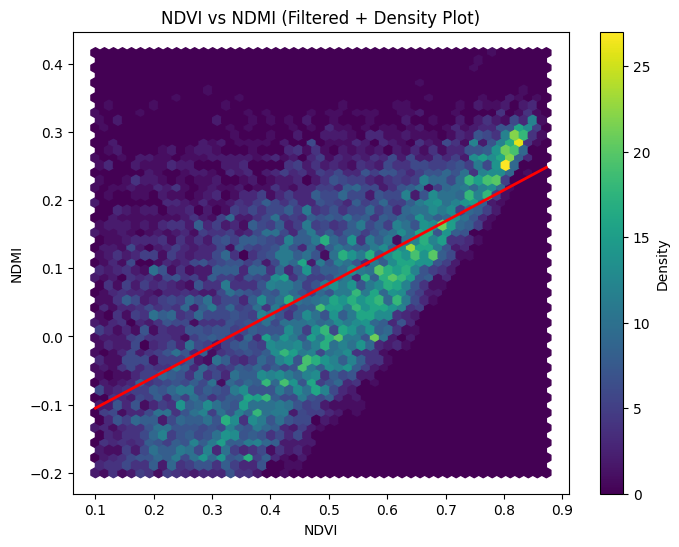

=== Correlation Result (Filtered) ===
R²: 0.387
Slope: 0.458
P-value: 0.00000


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# =======================
# 1. เตรียมข้อมูล
# =======================
df = pd.DataFrame({
    'NDVI': ndvi21.flatten(),
    'NDMI': ndmi21.flatten()
})

# ลบค่า NaN
df = df.dropna()

# =======================
# 2. กรอง noise (สำคัญมาก)
# =======================
# ตัดน้ำ / ดิน / ค่าผิดปกติ
df = df[
    (df['NDVI'] > 0.1) &   # พืชจริง
    (df['NDMI'] > -0.2)    # ตัดค่าผิดปกติ
]

# =======================
# 3. Sampling (ลดความแน่น)
# =======================
df_sample = df.sample(10000, random_state=42)

# =======================
# 4. Regression ใหม่
# =======================
slope, intercept, r_value, p_value, std_err = linregress(
    df_sample['NDVI'], df_sample['NDMI']
)

# =======================
# 5. Plot แบบ Hexbin (โปร)
# =======================
plt.figure(figsize=(8,6))

hb = plt.hexbin(
    df_sample['NDVI'],
    df_sample['NDMI'],
    gridsize=50,
    cmap='viridis'
)

plt.colorbar(hb, label='Density')

# เส้น regression
x = np.linspace(df_sample['NDVI'].min(), df_sample['NDVI'].max(), 100)
y = intercept + slope * x
plt.plot(x, y, color='red', linewidth=2)

plt.xlabel("NDVI")
plt.ylabel("NDMI")
plt.title("NDVI vs NDMI (Filtered + Density Plot)")

plt.show()

# =======================
# 6. แสดงผล
# =======================
print("=== Correlation Result (Filtered) ===")
print(f"R²: {r_value**2:.3f}")
print(f"Slope: {slope:.3f}")
print(f"P-value: {p_value:.5f}")